Images loaded successfully.
Keypoints in Image 1: 1000
Keypoints in Image 2: 1000
Good Matches: 11


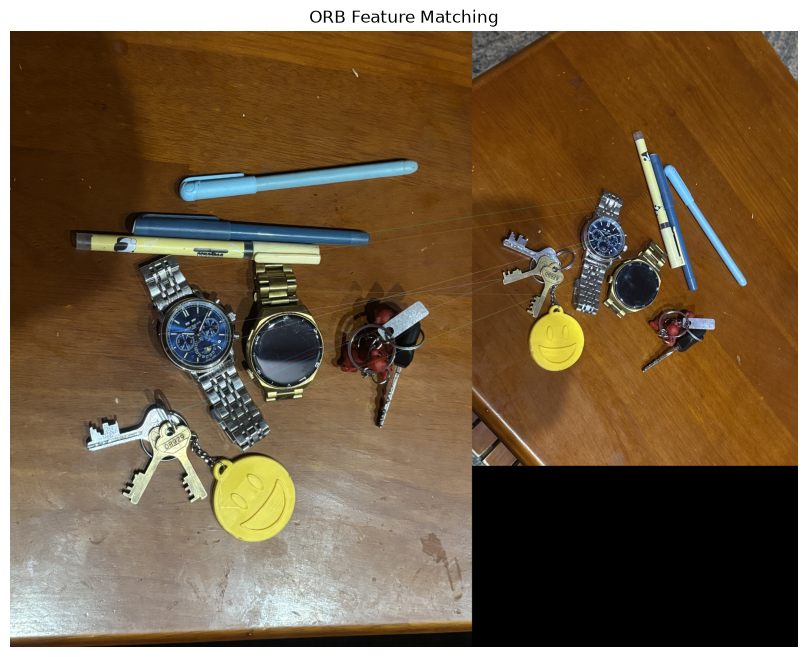

Total Keypoints in Image 1 : 1000
Total Keypoints in Image 2 : 1000
Good Matches : 11


In [1]:
# Task 7: Feature Matching Across Photos

## Aim

#To detect and match ORB features between two images of the same scene captured from different viewing angles.

## Theory

#Feature matching identifies corresponding points between two images. ORB (Oriented FAST and Rotated BRIEF) detects keypoints and computes descriptors that remain relatively stable even when the camera viewpoint changes. A Brute Force Matcher is then used to find matching descriptors between the two images.

import cv2
import matplotlib.pyplot as plt
img1 = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/objects.jpg")
img2 = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/objects_angle.jpg")

if img1 is None or img2 is None:
    print("Check image paths.")
else:
    print("Images loaded successfully.")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(1000)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Keypoints in Image 1:", len(kp1))
print("Keypoints in Image 2:", len(kp2))

bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des1, des2, k=2)

good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good Matches:", len(good_matches))

matched = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches[:50],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16,8))
plt.imshow(cv2.cvtColor(matched, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matching")
plt.axis("off")
plt.show()

print("Total Keypoints in Image 1 :", len(kp1))
print("Total Keypoints in Image 2 :", len(kp2))
print("Good Matches :", len(good_matches))

## Observation

#ORB successfully detected feature points in both images and matched them using the Brute Force Matcher.

#The strongest matches were observed on the **pen** and key because they contained distinct corners and textured regions that remained visible from different viewing angles.

#Some mismatches occurred due to changes in perspective and lighting, but most important objects were matched correctly.

## Conclusion

#The ORB feature detector successfully identified corresponding features between two images captured from different angles. Despite the viewpoint change, many reliable feature matches were obtained, demonstrating ORB's robustness for feature matching tasks.